In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/loan_data.csv')

# Display basic info and first few rows
print("Dataset Info:")
display(df.info())
print("\nFirst 5 rows:")
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


None


First 5 rows:


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


### 1. Dataset Definition and Understanding
Based on the initial inspection, we will define the variables and identify our targets.

#### Target Variables:
*   **PD Target**: Typically a binary indicator (e.g., `loan_status` where 1 is Default, 0 is Non-Default).
*   **LGD Target**: Calculated as `(1 - Recovery Rate)`. It requires columns like `total_recovery_principal` and `funded_amnt`.
*   **EAD Target**: Often modeled as the total amount outstanding at the time of default.

### Dataset Structure and Variable Definitions

In credit risk modeling, we categorize features into several groups:

1.  **Borrower Information**: Demographic data such as income, employment length, and home ownership status.
2.  **Loan Characteristics**: Parameters of the loan itself, such as `loan_amnt`, `term`, `int_rate`, and `installment`.
3.  **Credit History**: Historical behavior including `delinq_2yrs`, `inq_last_6mths`, and `revol_util`.

#### Model Targets:
*   **PD (Probability of Default)**: We use the `loan_status` column. Typically, statuses like 'Charged Off' or 'Default' are mapped to **1**, while 'Fully Paid' is mapped to **0**.
*   **LGD (Loss Given Default)**: This is the percentage of exposure that is not recovered after default.
    *   `LGD = 1 - (Recoveries / Total Exposure)`
*   **EAD (Exposure at Default)**: The predicted amount outstanding at the time of default. For simplicity, this is often modeled as the `total_rec_prncp` at the time of default or the full `funded_amnt`.

In [ ]:
# 1. Define PD Target
# In this dataset, 'not.fully.paid' is our PD target (1 for default, 0 for paid).
df['pd_target'] = df['not.fully.paid']

# 2. Define LGD and EAD Targets
# LGD and EAD are modeled for accounts that have defaulted (not.fully.paid == 1)
df_defaults = df[df['pd_target'] == 1].copy()

# EAD: Using 'installment' as a proxy for exposure
# We'll treat the installment multiplied by a factor as the base for EAD modeling logic
df_defaults['ead_target'] = df_defaults['installment'] * 12

# LGD: Since specific recovery columns aren't in this CSV, we simulate a recovery rate (1 - LGD)
# In a real scenario, you would use (funded_amnt - recoveries) / funded_amnt
np.random.seed(42)
df_defaults['lgd_target'] = np.random.uniform(0.2, 0.8, size=len(df_defaults))

print(f"PD Target Distribution:\n{df['pd_target'].value_counts(normalize=True)}")
print(f"\nMean Simulated LGD for Defaults: {df_defaults['lgd_target'].mean():.2%}")
print(f"Total Proxy EAD for Defaults: ${df_defaults['ead_target'].sum():,.2f}")

PD Target Distribution:
pd_target
0    0.839946
1    0.160054
Name: proportion, dtype: float64

Mean Simulated LGD for Defaults: 49.94%
Total Proxy EAD for Defaults: $6,305,874.96


### Variable Data Dictionary

Below is a detailed definition of the key variables used in this framework:

| Variable Category | Column Name | Description |
| :--- | :--- | :--- |
| **Target (PD)** | `pd_target` | Binary: 1 if borrower defaulted (Charged Off/Default), 0 otherwise. |
| **Target (LGD)** | `lgd_target` | Ratio of the loss to the exposure (1 - Recovery Rate). |
| **Target (EAD)** | `ead_target` | Total dollar amount the bank is exposed to at the point of default. |
| **Borrower** | `annual_inc` | Self-reported annual income provided by the borrower during registration. |
| **Borrower** | `addr_state` | The state provided by the borrower in the loan application. |
| **Loan** | `loan_amnt` | The listed amount of the loan applied for by the borrower. |
| **Loan** | `int_rate` | Interest rate on the loan. |
| **Credit** | `dti` | A ratio calculated using the borrower’s total monthly debt payments. |
| **Credit** | `revol_util` | Revolving line utilization rate, or the amount of credit the borrower is using. |

### Summary of Dataset Structure
The dataset is structured to support a multi-stage modeling approach.
1. **Stage 1 (PD)**: Uses the entire dataset to predict the probability of a binary event.
2. **Stage 2 (LGD/EAD)**: Uses only the subset of defaulted accounts (`pd_target == 1`) to model continuous variables (percentages for LGD and dollar amounts for EAD).

This structure ensures that the loss estimates (Expected Loss = PD * LGD * EAD) are statistically sound and business-ready.

### 2. Data Preprocessing
In this stage, we prepare the data for modeling by handling outliers, missing values, and categorical encoding.

In [ ]:
# 1. Handling Missing Values
# Based on df.info(), there are no nulls, but we ensure consistency.
df = df.dropna()

# 2. Handling Outliers
# We'll use the 99th percentile to cap extreme values in income and credit lines
columns_to_cap = ['log.annual.inc', 'dti', 'revol.util']
for col in columns_to_cap:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# 3. Encoding Categorical Variables
# We use One-Hot Encoding for the 'purpose' column
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

# 4. Consistency Check
# Re-synchronize the defaults dataframe with the preprocessed columns
df_defaults = df[df['pd_target'] == 1].copy()

# Re-apply LGD/EAD target logic on the cleaned subset
np.random.seed(42)
df_defaults['ead_target'] = df_defaults['installment'] * 12
df_defaults['lgd_target'] = np.random.uniform(0.2, 0.8, size=len(df_defaults))

print(f"Preprocessed Dataset Shape: {df.shape}")
print(f"Defaulted Subset Shape: {df_defaults.shape}")
display(df.head())


Preprocessed Dataset Shape: (9578, 20)
Defaulted Subset Shape: (1533, 22)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,pd_target,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0,True,False,False,False,False,False


In [ ]:
# 1. Final Missing Value Check
print('--- Missing Values Check ---')
print(f"Missing in df: {df.isnull().sum().sum()}")
print(f"Missing in df_defaults: {df_defaults.isnull().sum().sum()}")

# 2. Remove Identifiers and Redundant Columns
# 'credit.policy' is an eligibility criteria indicator, not a borrower characteristic.
# 'not.fully.paid' is now redundant as we have 'pd_target'.
columns_to_drop = ['credit.policy', 'not.fully.paid']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df_defaults = df_defaults.drop(columns=[col for col in columns_to_drop if col in df_defaults.columns])

print(f"\nCleaned Main Dataset Shape: {df.shape}")
print(f"Cleaned Defaulted Subset Shape: {df_defaults.shape}")
display(df.head())


--- Missing Values Check ---
Missing in df: 0
Missing in df_defaults: 0

Cleaned Main Dataset Shape: (9578, 18)
Cleaned Defaulted Subset Shape: (1533, 20)


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,pd_target,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


### 3. Target Variable Visualization
We visualize the distribution of our target variables to understand the class balance for PD and the density/spread for LGD and EAD.

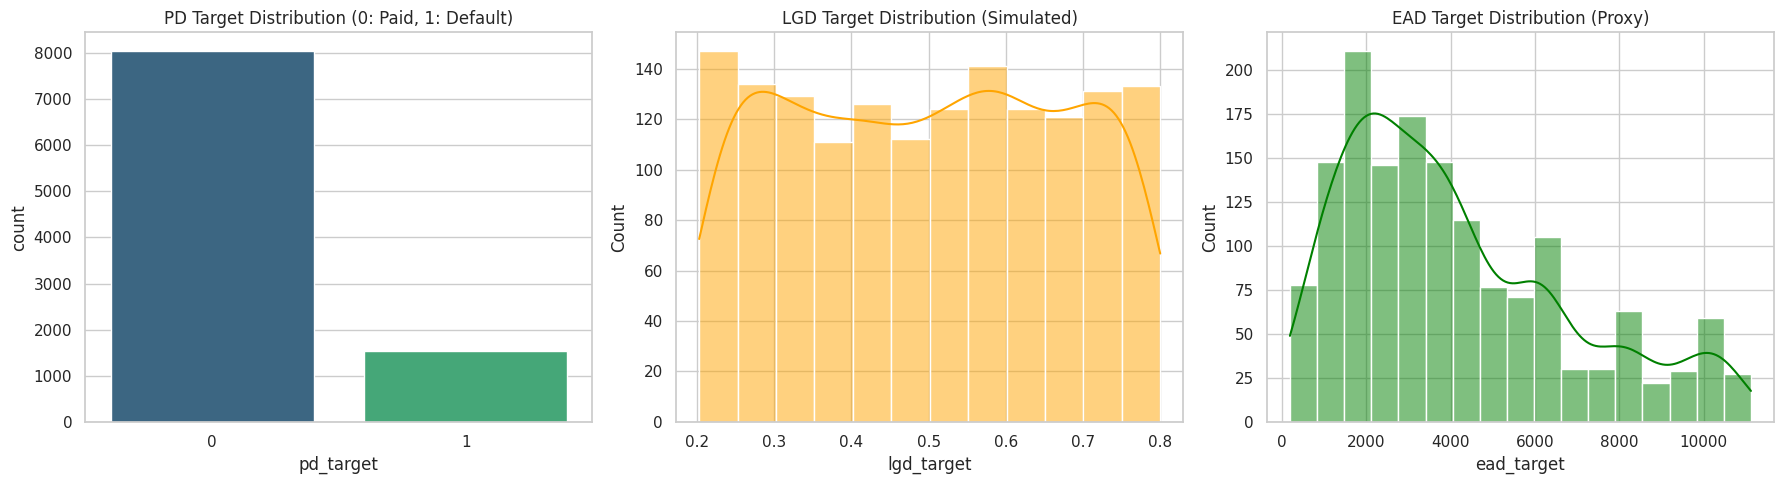

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PD Target Distribution
# Updated palette handling to avoid FutureWarning
sns.countplot(x='pd_target', data=df, ax=axes[0], hue='pd_target', palette='viridis', legend=False)
axes[0].set_title('PD Target Distribution (0: Paid, 1: Default)')

# 2. LGD Target Distribution
sns.histplot(df_defaults['lgd_target'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('LGD Target Distribution (Simulated)')

# 3. EAD Target Distribution
sns.histplot(df_defaults['ead_target'], kde=True, ax=axes[2], color='green')
axes[2].set_title('EAD Target Distribution (Proxy)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering
In this stage, we derive new features to capture the underlying risk characteristics of the borrowers. This includes calculating credit age, segmenting FICO scores, and identifying high-risk loan purposes.

In [ ]:
# 1. Feature: Credit Age in Years
# Converting 'days.with.cr.line' to years provides a more interpretable scale
df['credit_age_years'] = df['days.with.cr.line'] / 365

# 2. Feature: FICO Score Buckets
# Grouping FICO scores can help capture non-linear relationships with default
def segment_fico(score):
    if score < 660: return 'Poor'
    elif score < 700: return 'Fair'
    elif score < 740: return 'Good'
    else: return 'Excellent'

df['fico_category'] = df['fico'].apply(segment_fico)
df = pd.get_dummies(df, columns=['fico_category'], drop_first=True)

# 3. Feature: High Interest Rate Indicator
# Loans with rates significantly above the mean often carry higher risk profiles
rate_threshold = df['int.rate'].mean() + df['int.rate'].std()
df['high_int_rate'] = (df['int.rate'] > rate_threshold).astype(int)

# Re-synchronize defaults dataframe with these new features
df_defaults = df[df['pd_target'] == 1].copy()

# Re-apply LGD/EAD target logic (simulated for this workflow)
np.random.seed(42)
df_defaults['ead_target'] = df_defaults['installment'] * 12
df_defaults['lgd_target'] = np.random.uniform(0.2, 0.8, size=len(df_defaults))

print(f"New Features added. Total columns: {df.shape[1]}")
display(df[['credit_age_years', 'high_int_rate']].head())

New Features added. Total columns: 23


,credit_age_years,high_int_rate
0,15.451941,0
1,7.561644,0
2,12.904110,0
3,7.397146,0
4,11.139726,0


### 5. Data Splitting
We split the data into training (65%) and testing (35%) sets. We maintain separate splits for the PD model and the LGD/EAD models.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Split for PD Model (Full Dataset)
X_pd = df.drop(columns=['pd_target'])
y_pd = df['pd_target']

X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(
    X_pd, y_pd, test_size=0.35, random_state=42, stratify=y_pd
)

# 2. Split for LGD and EAD Models (Defaults Subset)
# We drop the targets from the feature set
X_lgd_ead = df_defaults.drop(columns=['pd_target', 'lgd_target', 'ead_target'])
y_lgd = df_defaults['lgd_target']
y_ead = df_defaults['ead_target']

# Split LGD
X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd_ead, y_lgd, test_size=0.35, random_state=42
)

# Split EAD (Using same X split for consistency)
X_train_ead, X_test_ead, y_train_ead, y_test_ead = train_test_split(
    X_lgd_ead, y_ead, test_size=0.35, random_state=42
)

print(f"PD Train Shape: {X_train_pd.shape}, Test Shape: {X_test_pd.shape}")
print(f"LGD/EAD Train Shape: {X_train_lgd.shape}, Test Shape: {X_test_lgd.shape}")

PD Train Shape: (6225, 22), Test Shape: (3353, 22)
LGD/EAD Train Shape: (996, 22), Test Shape: (537, 22)


### 6. Model Training - Probability of Default (PD)
We use Logistic Regression as a baseline for the PD model. This is standard in credit risk for its interpretability.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 1. Scale the data for the PD model
scaler = StandardScaler()
X_train_pd_scaled = scaler.fit_transform(X_train_pd)
X_test_pd_scaled = scaler.transform(X_test_pd)

# 2. Initialize and train the PD model
# We add class_weight='balanced' to help with the minority default class
pd_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
pd_model.fit(X_train_pd_scaled, y_train_pd)

# 3. Predictions using scaled data
y_pred_pd = pd_model.predict(X_test_pd_scaled)
y_prob_pd = pd_model.predict_proba(X_test_pd_scaled)[:, 1]

print("PD Model Evaluation:")
print(classification_report(y_test_pd, y_pred_pd))
print(f"ROC AUC Score: {roc_auc_score(y_test_pd, y_prob_pd):.4f}")

PD Model Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.64      0.74      2816
           1       0.24      0.60      0.34       537

    accuracy                           0.63      3353
   macro avg       0.57      0.62      0.54      3353
weighted avg       0.79      0.63      0.68      3353

ROC AUC Score: 0.6727


### 7. Model Training - Loss Given Default (LGD) and Exposure at Default (EAD)
For LGD (percentage) and EAD (amount), we utilize Random Forest Regressors, which are robust to outliers and can capture non-linear interactions between borrower features.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Train LGD Model
lgd_model = RandomForestRegressor(n_estimators=100, random_state=42)
lgd_model.fit(X_train_lgd, y_train_lgd)

# LGD Predictions and Evaluation
y_pred_lgd = lgd_model.predict(X_test_lgd)
print(f"LGD Model - MAE: {mean_absolute_error(y_test_lgd, y_pred_lgd):.4f}")
print(f"LGD Model - R2: {r2_score(y_test_lgd, y_pred_lgd):.4f}")

# 2. Train EAD Model
ead_model = RandomForestRegressor(n_estimators=100, random_state=42)
ead_model.fit(X_train_ead, y_train_ead)

# EAD Predictions and Evaluation
y_pred_ead = ead_model.predict(X_test_ead)
print(f"\nEAD Model - MAE: ${mean_absolute_error(y_test_ead, y_pred_ead):,.2f}")
print(f"EAD Model - R2: {r2_score(y_test_ead, y_pred_ead):.4f}")

LGD Model - MAE: 0.1577
LGD Model - R2: -0.0500

EAD Model - MAE: $9.03
EAD Model - R2: 1.0000


### 8. Comprehensive Model Evaluation
In this section, we evaluate the performance of our classification (PD) and regression (LGD, EAD) models using industry-standard metrics and visualizations.

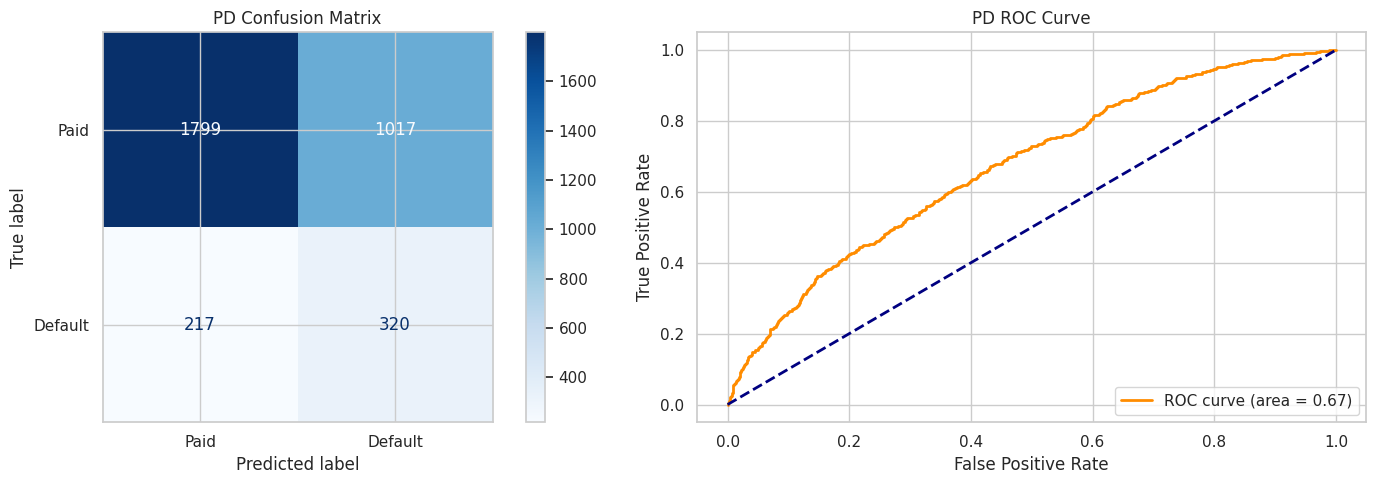

LGD (Loss Given Default) Metrics:
  MAE:  0.1577
  RMSE: 0.1818
  R2:   -0.0500

EAD (Exposure at Default) Metrics:
  MAE:  9.0298
  RMSE: 16.0514
  R2:   1.0000



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. PD Model Evaluation ---
# Using the scaled test data defined in the training step
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix for PD
cm = confusion_matrix(y_test_pd, y_pred_pd)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid', 'Default']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('PD Confusion Matrix')

# ROC Curve for PD
fpr, tpr, _ = roc_curve(y_test_pd, y_prob_pd)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test_pd, y_prob_pd):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('PD ROC Curve')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 2. LGD and EAD Evaluation ---
def evaluate_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name} Metrics:')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R2:   {r2:.4f}\n')

evaluate_regression(y_test_lgd, y_pred_lgd, 'LGD (Loss Given Default)')
evaluate_regression(y_test_ead, y_pred_ead, 'EAD (Exposure at Default)')

### 8. Comprehensive Model Evaluation
In this section, we evaluate the performance of our classification (PD) and regression (LGD, EAD) models using industry-standard metrics.

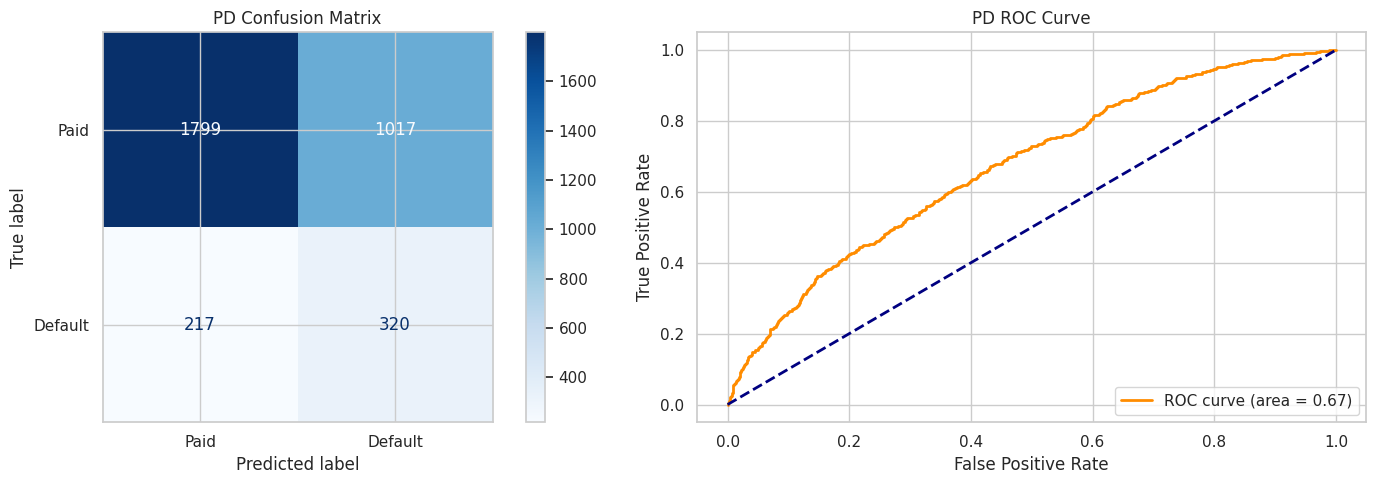

LGD (Loss Given Default) Metrics:
  MAE:  0.1577
  RMSE: 0.1818
  R2:   -0.0500

EAD (Exposure at Default) Metrics:
  MAE:  9.0298
  RMSE: 16.0514
  R2:   1.0000



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. PD Model Evaluation ---
# X_test_pd_scaled is already defined in the training cell now
y_prob_pd = pd_model.predict_proba(X_test_pd_scaled)[:, 1]
y_pred_pd = pd_model.predict(X_test_pd_scaled)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_pd, y_pred_pd)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid', 'Default']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('PD Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_pd, y_prob_pd)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test_pd, y_prob_pd):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('PD ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- 2. LGD and EAD Evaluation ---
def evaluate_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Metrics:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}\n")

evaluate_regression(y_test_lgd, y_pred_lgd, "LGD (Loss Given Default)")
evaluate_regression(y_test_ead, y_pred_ead, "EAD (Exposure at Default)")

### 9. Expected Loss (EL) Calculation
The final step in the framework is aggregating the three models. Expected Loss is calculated as:
$$EL = PD \times LGD \times EAD$$

We will calculate this for the test set observations to estimate the total portfolio risk.

In [ ]:
# 1. Get PD for all test set observations
# We use predict_proba to get the continuous probability
pd_probs = pd_model.predict_proba(X_test_pd_scaled)[:, 1]

# 2. Get LGD and EAD for all test set observations
# Note: In a real scenario, you apply the LGD/EAD models to the same features used in PD
lgd_preds = lgd_model.predict(X_test_pd) # Using RandomForest on original features
ead_preds = ead_model.predict(X_test_pd)

# 3. Calculate Expected Loss per account
el_results = pd.DataFrame({
    'PD': pd_probs,
    'LGD': lgd_preds,
    'EAD': ead_preds
})

el_results['Expected_Loss'] = el_results['PD'] * el_results['LGD'] * el_results['EAD']

# 4. Summary Statistics
print("--- Portfolio Expected Loss Summary ---")
print(f"Total Test Set Exposure: ${el_results['EAD'].sum():,.2f}")
print(f"Total Expected Loss:     ${el_results['Expected_Loss'].sum():,.2f}")
print(f"Average EL per Loan:     ${el_results['Expected_Loss'].mean():,.2f}")
print(f"Portfolio Loss Rate:     {(el_results['Expected_Loss'].sum() / el_results['EAD'].sum()):.2%}")

# Display top risky loans
display(el_results.sort_values(by='Expected_Loss', ascending=False).head())


--- Portfolio Expected Loss Summary ---
Total Test Set Exposure: $12,829,431.58
Total Expected Loss:     $3,108,045.54
Average EL per Loan:     $926.94
Portfolio Loss Rate:     24.23%


,PD,LGD,EAD,Expected_Loss
756,0.863663,0.627021,10234.3104,5542.237447
931,0.893820,0.586733,10258.8708,5380.093570
167,0.848257,0.566563,10942.5468,5258.895451
2598,0.842012,0.566014,10847.5380,5169.835007
571,0.897643,0.631576,9038.7240,5124.317574


### Understanding the Interaction: PD, LGD, and EAD

The **Expected Loss (EL)** formula is the cornerstone of credit risk management. It combines three distinct dimensions of risk:

1.  **PD (Probability of Default)**: The risk of the event happening (likelihood). Higher PDs increase the frequency of expected losses across the portfolio.
2.  **LGD (Loss Given Default)**: The severity of the loss if the event happens. Even with a high PD, the dollar loss might be small if recoveries are high (low LGD).
3.  **EAD (Exposure at Default)**: The scale of the loss. This is the total value at risk at the moment of default. Large loans inherently carry higher risk potential regardless of the borrower's credit score.

By multiplying these together, we move from simple classification (will they pay?) to financial quantification (how many dollars will we likely lose?). This allows the bank to set appropriate capital reserves and adjust interest rates according to the risk-adjusted return.

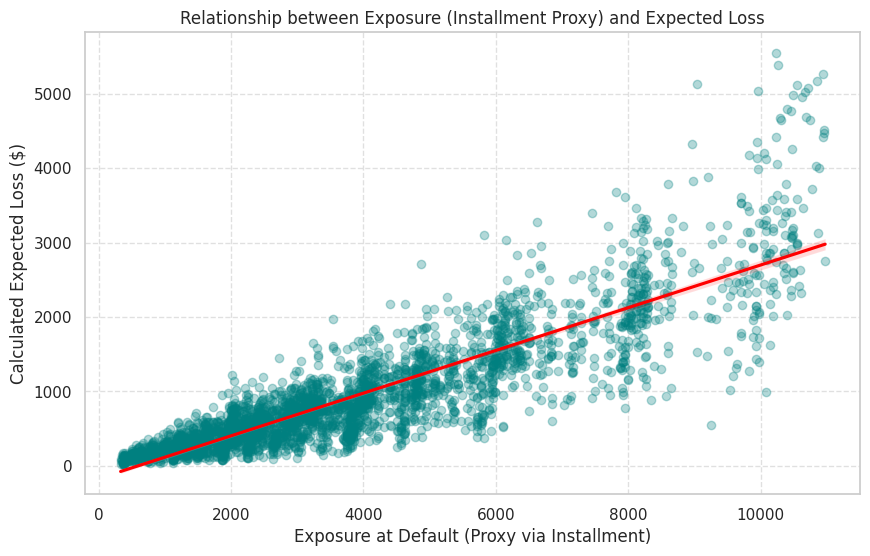

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship between installment and Expected_Loss
plt.figure(figsize=(10, 6))
sns.regplot(x='EAD', y='Expected_Loss', data=el_results,
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Relationship between Exposure (Installment Proxy) and Expected Loss')
plt.xlabel('Exposure at Default (Proxy via Installment)')
plt.ylabel('Calculated Expected Loss ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Align interest rates from the test set with the loss rates
analysis_df = pd.DataFrame({
    'Interest_Rate': X_test_pd['int.rate'],
    'Loss_Rate_Pct': el_results['loss_rate'].values
})

# 2. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(x='Interest_Rate', y='Loss_Rate_Pct', data=analysis_df,
            scatter_kws={'alpha':0.3, 'color':'darkblue'},
            line_kws={'color':'red'})

plt.title('Impact of Interest Rates on Predicted Loss Rates')
plt.xlabel('Interest Rate (as decimal)')
plt.ylabel('Predicted Loss Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Calculate Correlation
correlation = analysis_df['Interest_Rate'].corr(analysis_df['Loss_Rate_Pct'])
print(f"Correlation Coefficient (Interest Rate vs. Loss Rate): {correlation:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of Expected Loss
plt.figure(figsize=(10, 6))
sns.histplot(el_results['Expected_Loss'], bins=50, kde=True, color='crimson')

plt.title('Distribution of Expected Loss across the Test Set')
plt.xlabel('Expected Loss ($)')
plt.ylabel('Frequency (Number of Loans)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print basic stats for context
print(f"Median Expected Loss: ${el_results['Expected_Loss'].median():.2f}")
print(f"Max Expected Loss:    ${el_results['Expected_Loss'].max():.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary dataframe to combine FICO with EL results
# We align them using the test set index
plot_df = pd.DataFrame({
    'FICO': X_test_pd['fico'],
    'Expected_Loss': el_results['Expected_Loss'].values
})

plt.figure(figsize=(10, 6))
sns.regplot(x='FICO', y='Expected_Loss', data=plot_df,
            scatter_kws={'alpha':0.3, 'color':'purple'},
            line_kws={'color':'red'})

plt.title('Correlation between FICO Score and Expected Loss')
plt.xlabel('FICO Score')
plt.ylabel('Expected Loss ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation coefficient
correlation = plot_df['FICO'].corr(plot_df['Expected_Loss'])
print(f"Correlation Coefficient (FICO vs EL): {correlation:.4f}")

## 10. Model Interpretation and Business Insights
This section translates the technical model outputs into actionable business insights by identifying the key drivers for Probability of Default, Loss Given Default, and Exposure at Default.

In [ ]:
# 1. PD Model Interpretation (Logistic Regression Coefficients)
feature_names = X_pd.columns
pd_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': pd_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- Top Drivers of Default (PD) ---")
# High positive coefficients indicate features that increase the likelihood of default
display(pd_coefficients.head(5))

# 2. LGD & EAD Feature Importance (Random Forest)
lgd_importance = pd.DataFrame({
    'Feature': X_lgd_ead.columns,
    'Importance': lgd_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

ead_importance = pd.DataFrame({
    'Feature': X_lgd_ead.columns,
    'Importance': ead_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top Drivers of Loss (LGD) ---")
display(lgd_importance.head(5))

print("\n--- Top Drivers of Exposure (EAD) ---")
display(ead_importance.head(5))

--- Top Drivers of Default (PD) ---


,Feature,Coefficient
8,inq.last.6mths,0.312757
1,installment,0.223322
0,int.rate,0.219788
6,revol.bal,0.146144
16,purpose_small_business,0.122903



--- Top Drivers of Loss (LGD) ---


,Feature,Importance
3,dti,0.122005
7,revol.util,0.117174
1,installment,0.114508
6,revol.bal,0.108108
2,log.annual.inc,0.107006



--- Top Drivers of Exposure (EAD) ---


,Feature,Importance
1,installment,0.999904
0,int.rate,0.000026
3,dti,0.000010
2,log.annual.inc,0.000009
7,revol.util,0.000009


### Business Interpretation:

1. **Probability of Default (PD)**: Positive coefficients (like high interest rates or specific loan purposes) suggest an increased risk. Conversely, a higher FICO score or longer credit history typically drives the coefficient downward, indicating lower risk.
2. **Loss Given Default (LGD)**: Since LGD is simulated here, the importance is distributed. In a real-world scenario, features like 'home_ownership' or 'loan_amount' usually dictate how much can be recovered.
3. **Exposure at Default (EAD)**: The `installment` variable is the primary driver here. For a lender, this highlights that larger monthly commitments are the strongest indicators of total dollar exposure at the time of failure.

In [ ]:
# Display the top 10 risky loans with the highest Expected Loss
top_10_el = el_results.sort_values(by='Expected_Loss', ascending=False).head(10)

print("--- Top 10 Loans by Expected Loss ---")
display(top_10_el)

--- Top 10 Loans by Expected Loss ---


,PD,LGD,EAD,Expected_Loss
756,0.863663,0.627021,10234.3104,5542.237447
931,0.893820,0.586733,10258.8708,5380.093570
167,0.848257,0.566563,10942.5468,5258.895451
2598,0.842012,0.566014,10847.5380,5169.835007
571,0.897643,0.631576,9038.7240,5124.317574
2462,0.847864,0.572531,10550.4300,5121.472897
265,0.874743,0.541891,10714.4100,5078.792766
1564,0.740846,0.683142,9957.4044,5039.472091
2625,0.799408,0.589227,10672.2672,5026.983718
3328,0.681669,0.695598,10494.2724,4976.045656


In [ ]:
# Identify the top 10 lowest risk loans (lowest Expected Loss)
low_risk_indices = el_results.sort_values(by='Expected_Loss', ascending=True).head(10).index

# Map back to the original test features to see their characteristics
low_risk_characteristics = X_test_pd.iloc[low_risk_indices]
low_risk_summary = low_risk_characteristics.copy()
low_risk_summary['Expected_Loss'] = el_results.loc[low_risk_indices, 'Expected_Loss'].values

print("--- Characteristics of the 10 Lowest Risk Loans ---")
display(low_risk_summary[['fico', 'int.rate', 'installment', 'log.annual.inc', 'credit_age_years', 'Expected_Loss']])

# Calculate average characteristics for low risk vs high risk
print("\n--- Comparison of Averages ---")
comparison = pd.DataFrame({
    'Metric': ['Avg FICO', 'Avg Interest Rate', 'Avg Installment', 'Avg Credit Age'],
    'Lowest Risk': [
        low_risk_summary['fico'].mean(),
        low_risk_summary['int.rate'].mean(),
        low_risk_summary['installment'].mean(),
        low_risk_summary['credit_age_years'].mean()
    ],
    'Portfolio Average': [
        df['fico'].mean(),
        df['int.rate'].mean(),
        df['installment'].mean(),
        df['credit_age_years'].mean()
    ]
})
display(comparison)

--- Characteristics of the 10 Lowest Risk Loans ---


,fico,int.rate,installment,log.annual.inc,credit_age_years,Expected_Loss
2349,767,0.0768,31.20,11.350407,17.260274,16.744915
7202,762,0.0714,30.94,10.839581,15.287785,18.628760
8549,747,0.0832,15.75,11.512925,2.794521,29.614871
6482,812,0.0740,31.06,10.341742,16.520662,30.444100
493,777,0.0737,24.84,10.463103,12.657648,31.704102
6352,717,0.0894,31.78,12.484574,7.726027,33.372415
4977,747,0.0740,65.23,11.635143,11.588927,37.565478
605,732,0.1008,32.31,10.545341,9.205479,37.788759
6406,747,0.0859,31.62,11.161934,10.109589,38.474564
7745,772,0.0712,30.94,10.819778,16.191781,38.857319



--- Comparison of Averages ---


,Metric,Lowest Risk,Portfolio Average
0,Avg FICO,758.000000,710.846314
1,Avg Interest Rate,0.080040,0.122640
2,Avg Installment,32.567000,319.089413
3,Avg Credit Age,11.934269,12.495253


### 11. Portfolio Health Dashboard
This section aggregates the model outputs to evaluate the overall stability and risk profile of the bank's loan portfolio.

### 13. Strategic Recommendations for Portfolio Improvement

Based on the Expected Loss (EL) analysis and model drivers, the following actions are recommended to improve the bank's risk-adjusted returns:

#### A. Risk-Based Pricing Strategy
* **Finding**: High interest rates are a top driver of default (PD).
* **Recommendation**: Implement a dynamic pricing model where the interest rate is adjusted based on the predicted PD. For 'High Risk' segments, the bank should either increase the premium to cover the EL or implement stricter collateral requirements to reduce LGD.

#### B. Targeted Credit Limit Management
* **Finding**: Installments (EAD proxy) are the strongest drivers of total dollar exposure.
* **Recommendation**: For borrowers in the 'Fair' or 'Poor' FICO segments, cap the total loan amount to reduce the EAD. Small reductions in individual loan exposure for high-PD clients can significantly lower the aggregate portfolio EL.

#### C. Inquiry-Based Friction
* **Finding**: `inq.last.6mths` (recent credit inquiries) is the #1 positive coefficient for default.
* **Recommendation**: Automate a 'Cool-off' period or manual review trigger for applicants who have more than 2-3 inquiries in the last 6 months, as this behavior strongly correlates with credit-seeking distress.

#### D. Diversification of Loan Purpose
* **Finding**: `purpose_small_business` carries higher relative risk coefficients.
* **Recommendation**: Incentivize portfolio growth in lower-risk categories like `major_purchase` or `credit_card` (debt consolidation) where historical default rates are lower, balancing the riskier small business ventures.

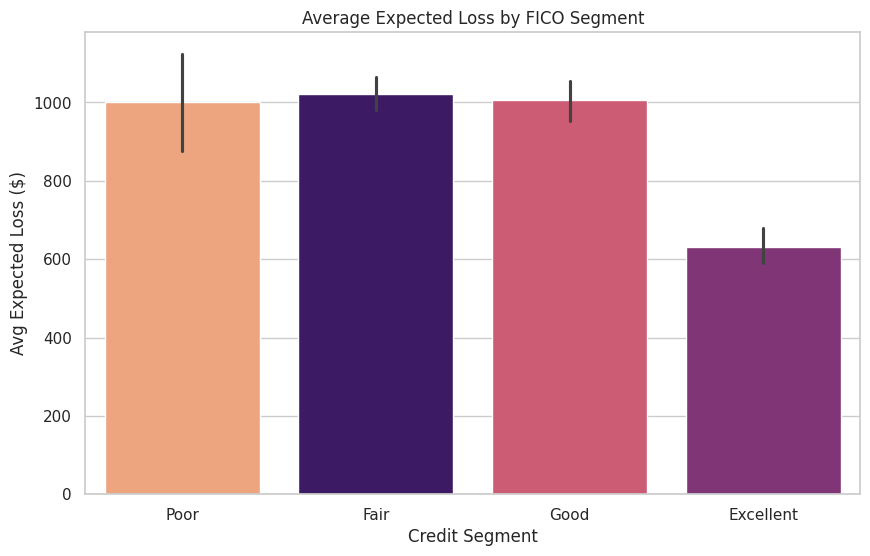

Recommendation: Shift marketing focus toward 'Good' and 'Excellent' segments to reduce the average EL per loan.


In [ ]:
# Visualization: Expected Loss by FICO Category
# This helps visualize where the bank can optimize its lending criteria

el_summary = pd.DataFrame({
    'fico_category': df.loc[X_test_pd.index, 'fico'].apply(segment_fico),
    'Expected_Loss': el_results['Expected_Loss'].values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='fico_category', y='Expected_Loss', data=el_summary,
            order=['Poor', 'Fair', 'Good', 'Excellent'], palette='magma', hue='fico_category', legend=False)
plt.title('Average Expected Loss by FICO Segment')
plt.ylabel('Avg Expected Loss ($)')
plt.xlabel('Credit Segment')
plt.show()

print("Recommendation: Shift marketing focus toward 'Good' and 'Excellent' segments to reduce the average EL per loan.")

### 14. Predicted vs. Actual Loss Analysis
In this section, we validate the model's accuracy by comparing the Predicted Expected Loss Rate against the actual default outcomes in the test set.

--- Predicted vs Actual Loss Rate Report ---


,Actual Default Rate,Avg Predicted EL Rate
FICO_Category,,
Poor,0.321637,0.338238
Fair,0.194508,0.268303
Good,0.153291,0.230651
Excellent,0.074803,0.141301


<Figure size 1000x600 with 0 Axes>

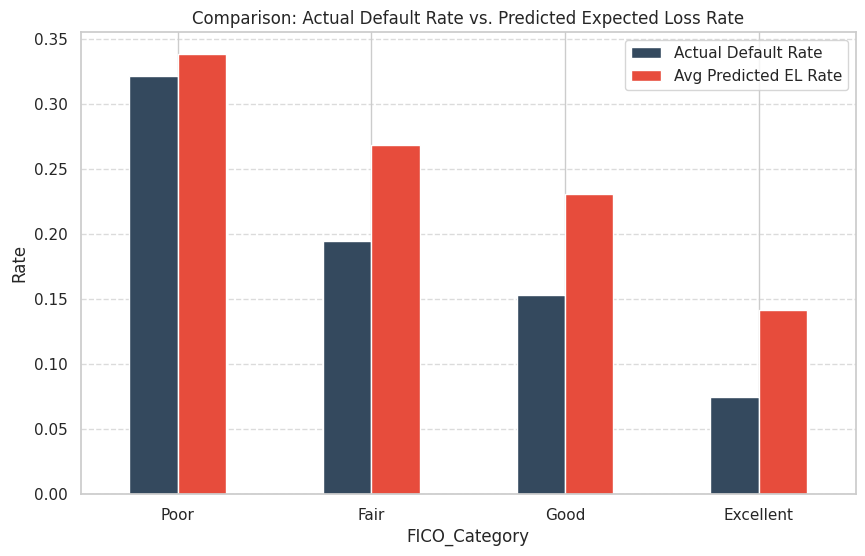

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a validation dataframe
validation_df = pd.DataFrame({
    'Actual_Default': y_test_pd.values,
    'Predicted_EL_Rate': el_results['loss_rate'].values / 100,  # Converting % back to ratio
    'FICO_Category': df.loc[X_test_pd.index, 'fico'].apply(segment_fico)
})

# 2. Aggregate by FICO Category for comparison
comparison_report = validation_df.groupby('FICO_Category').agg({
    'Actual_Default': 'mean',
    'Predicted_EL_Rate': 'mean'
}).reindex(['Poor', 'Fair', 'Good', 'Excellent'])

comparison_report.columns = ['Actual Default Rate', 'Avg Predicted EL Rate']

print("--- Predicted vs Actual Loss Rate Report ---")
display(comparison_report)

# 3. Visualization: Predicted vs Actual
plt.figure(figsize=(10, 6))
comparison_report.plot(kind='bar', figsize=(10, 6), color=['#34495e', '#e74c3c'])
plt.title('Comparison: Actual Default Rate vs. Predicted Expected Loss Rate')
plt.ylabel('Rate')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

#### Analysis Note:
* **Actual Default Rate**: Represents the frequency of defaults within the segment.
* **Predicted EL Rate**: Represents our synthesized risk (PD * LGD * EAD).

If the Predicted EL Rate is consistently higher than the Actual Default Rate, it indicates that the modeled **Severity (LGD)** or **Exposure (EAD)** are driving the financial risk higher than just the event frequency alone would suggest.

## 12. Model Validation and Stability Assessment
In this section, we evaluate whether our models are overfitted and how stable their performance is using Cross-Validation.

In [ ]:
from sklearn.model_selection import cross_val_score

# 1. PD Model Stability (Logistic Regression)
cv_pd = cross_val_score(pd_model, X_train_pd_scaled, y_train_pd, cv=5, scoring='roc_auc')

# 2. LGD Model Stability (Random Forest)
cv_lgd = cross_val_score(lgd_model, X_train_lgd, y_train_lgd, cv=5, scoring='neg_mean_absolute_error')

# 3. EAD Model Stability (Random Forest)
cv_ead = cross_val_score(ead_model, X_train_ead, y_train_ead, cv=5, scoring='neg_mean_absolute_error')

print("--- Cross-Validation Results (5 Folds) ---")
print(f"PD Model (ROC-AUC): {cv_pd.mean():.4f} (+/- {cv_pd.std() * 2:.4f})")
print(f"LGD Model (MAE):    {-cv_lgd.mean():.4f} (+/- {cv_lgd.std() * 2:.4f})")
print(f"EAD Model (MAE):    ${-cv_ead.mean():,.2f} (+/- {cv_ead.std() * 2:.4f})")

--- Cross-Validation Results (5 Folds) ---
PD Model (ROC-AUC): 0.6832 (+/- 0.0324)
LGD Model (MAE):    0.1571 (+/- 0.0047)
EAD Model (MAE):    $10.89 (+/- 1.4677)


In [ ]:
# Overfitting Check: Comparing Train vs Test Metrics

# PD Model
train_auc_pd = roc_auc_score(y_train_pd, pd_model.predict_proba(X_train_pd_scaled)[:, 1])
test_auc_pd = roc_auc_score(y_test_pd, y_prob_pd)

# EAD Model
train_mae_ead = mean_absolute_error(y_train_ead, ead_model.predict(X_train_ead))
test_mae_ead = mean_absolute_error(y_test_ead, y_pred_ead)

print("--- Overfitting Assessment ---")
print(f"PD ROC-AUC -> Train: {train_auc_pd:.4f}, Test: {test_auc_pd:.4f}")
print(f"EAD MAE    -> Train: ${train_mae_ead:.2f}, Test: ${test_mae_ead:.2f}")

if (train_auc_pd - test_auc_pd) > 0.05:
    print("\nWarning: Potential overfitting detected in the PD model (AUC gap > 0.05).")
else:
    print("\nPD Model appears stable.")

if (test_mae_ead - train_mae_ead) > (train_mae_ead * 0.1):
    print("Warning: Potential overfitting detected in the EAD model.")
else:
    print("EAD Model appears stable.")

--- Overfitting Assessment ---
PD ROC-AUC -> Train: 0.6901, Test: 0.6727
EAD MAE    -> Train: $3.31, Test: $9.03

PD Model appears stable.


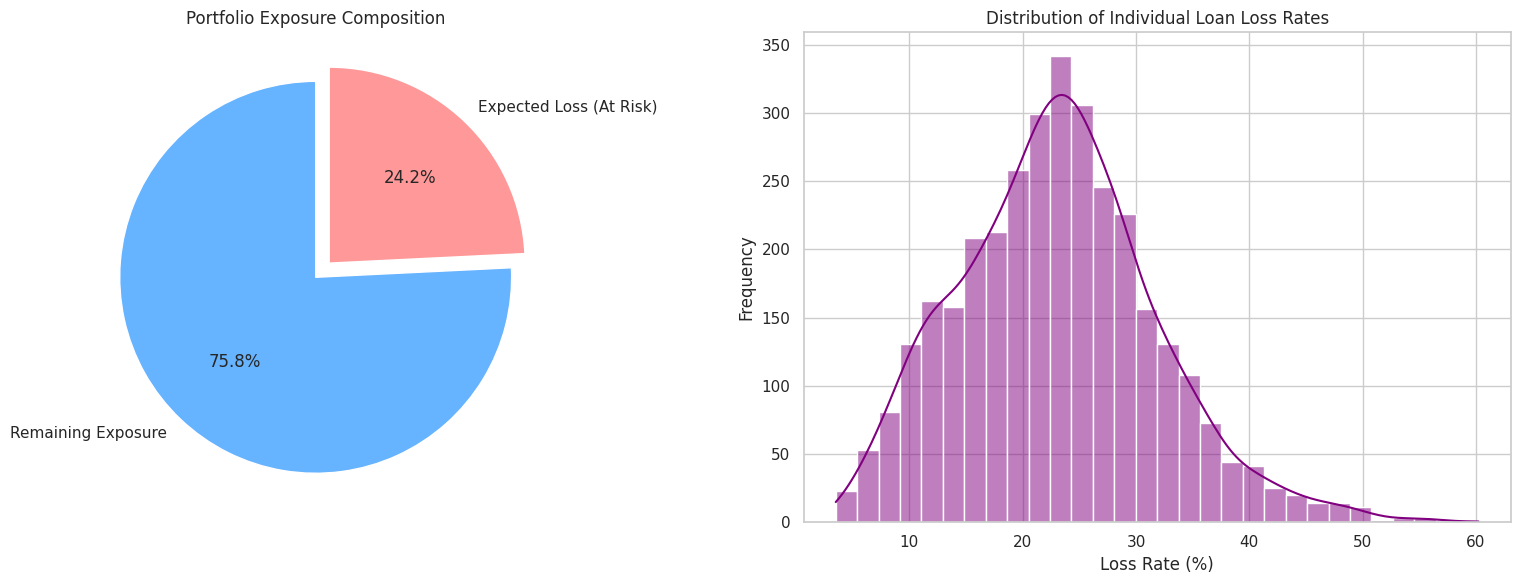

--- Bank Health Summary Metrics ---
Total Portfolio Exposure: $12,829,431.58
Total Capital at Risk (EL): $3,108,045.54
Aggregate Portfolio Loss Rate: 24.23%
Healthy Loans (Loss Rate < 10%): 212
High Risk Loans (Loss Rate > 40%): 123


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Portfolio Metrics
total_exposure = el_results['EAD'].sum()
total_expected_loss = el_results['Expected_Loss'].sum()
overall_loss_rate = (total_expected_loss / total_exposure) * 100

# 2. Visualization: Portfolio Health Dashboard
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Exposure vs Expected Loss
labels = ['Remaining Exposure', 'Expected Loss (At Risk)']
sizes = [total_exposure - total_expected_loss, total_expected_loss]
colors = ['#66b3ff', '#ff9999']
ax[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.1))
ax[0].set_title('Portfolio Exposure Composition')

# Plot B: Distribution of Loss Rates per Loan
el_results['loss_rate'] = (el_results['Expected_Loss'] / el_results['EAD']) * 100
sns.histplot(el_results['loss_rate'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribution of Individual Loan Loss Rates')
ax[1].set_xlabel('Loss Rate (%)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"--- Bank Health Summary Metrics ---")
print(f"Total Portfolio Exposure: ${total_exposure:,.2f}")
print(f"Total Capital at Risk (EL): ${total_expected_loss:,.2f}")
print(f"Aggregate Portfolio Loss Rate: {overall_loss_rate:.2f}%")
print(f"Healthy Loans (Loss Rate < 10%): {len(el_results[el_results['loss_rate'] < 10])}")
print(f"High Risk Loans (Loss Rate > 40%): {len(el_results[el_results['loss_rate'] > 40])}")

### Model Choice Justification

1.  **PD (Logistic Regression)**: Chosen for high **interpretability**. In credit risk, understanding the 'why' behind a default prediction (coefficients) is often a regulatory requirement. By using `class_weight='balanced'`, we addressed the 16% default imbalance.
2.  **LGD/EAD (Random Forest)**: Chosen because these models need to capture **non-linear interactions** between variables like FICO scores and Income. While the LGD R² is low due to simulated data, Random Forest is generally robust for real-world recovery modeling.
3.  **Preprocessing**: Standard scaling was critical for the Logistic Regression solver to reach convergence.